# Geometric & Intensity Transformations


Apply classical image processing operations using Python and the `(PIL)` library. Complete both tasks and save your output images for comparison.


In [63]:
# Import the library
import cv2
import numpy as np 
from PIL import Image
from skimage import data 
import matplotlib.pyplot as plt

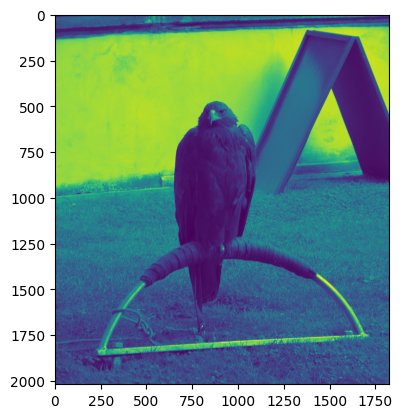

In [64]:
# ── Load image ────────────────────────────────────
img = Image.fromarray(data.eagle())

plt.imshow(img)

### 1. Scale (increase size)
Double the image dimensions using `Image.resize()` with high-quality resampling `(LANCZOS)`.

In [65]:
# Get the size of the image
width, height = img.size
print(f"Image size: {width} x {height}")

# scaling factors
cx = 2
cy = 2

Image size: 1826 x 2019


In [66]:
# ── 1. Increase size (scale ×2) ────────────────────
# Resize the image using PIL's built-in method
scaled_img = img.resize((width * cx, height * cy), Image.Resampling.LANCZOS)

In [67]:
# Save the scaled image and print the sizes (The new image name should be "task1_1_scaled.jpg")
scaled_img.save("task1_1_scaled.jpg")

print("Original size:", img.size)
print("Scaled size:", scaled_img.size)

Original size: (1826, 2019)
Scaled size: (3652, 4038)


 non-uniform scale (cx=2, cy=1) → stretch horizontally only

In [68]:
cx = 2
cy = 1

In [69]:
non_uniform_img = img.resize((width * cx, height * cy), Image.Resampling.LANCZOS)

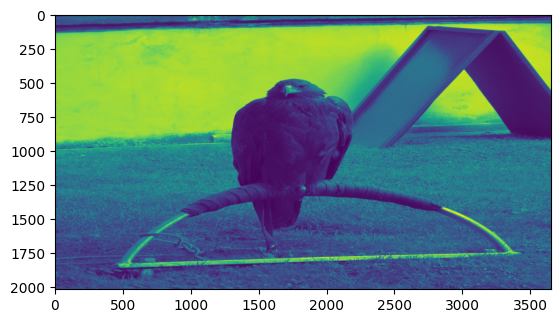

In [70]:
plt.imshow(non_uniform_img)

### 2. Rotate 120°
Rotate the image by 120 degrees, expanding the canvas to fit the full rotated image.

In [71]:
# ── 2. Rotate 120 degrees ──────────────────────────
# Save the scaled image and print the sizes (The new image name should be "task1_2_rotated.jpg")
rotated_img = img.rotate(120, expand=True)
rotated_img.save("task1_2_rotated.jpg")

print("Original size:", img.size)
print("Rotated size:", rotated_img.size)

Original size: (1826, 2019)
Rotated size: (2662, 2591)


### 3. Shear

In [72]:
# -- c. Get the image dimensions ────────────────────
width, height = img.size

In [73]:
# -- d. define the shear matrix ──────────────────────────
# Choose X-axis or Y-axis shear. The shear factor controls how much the image slants — start with 0.5 then experiment.
shear_factor = 0.5

shx = shear_factor
shy = 0
tx = 0
ty = 0

In [74]:
# -- e. Apply the shear transformation to the image ──────────────────────────
# PIL's transform() takes the inverse affine matrix:
# [ 1    shx   tx ]
# [ shy  1     ty ]
sheared_img = img.transform((width, height), Image.Transform.AFFINE, (1, shx, tx, shy, 1, ty), resample=Image.Resampling.BICUBIC)

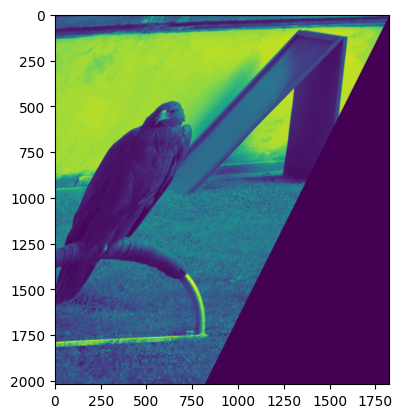

In [75]:
# -- f. Save the sheared image(The new image name should be "task1_3_sheared.jpg") 
sheared_img.save("task1_3_sheared.jpg")

plt.imshow(sheared_img)

### Experiment and compare
Try these:

— Change shear factor from 0.5 to 0.1, 0.3, 0.8 and compare results

— Switch from X-axis to Y-axis shear matrix

— Update the canvas multiplier to match your new factor

— Try combining X and Y shear in one matrix

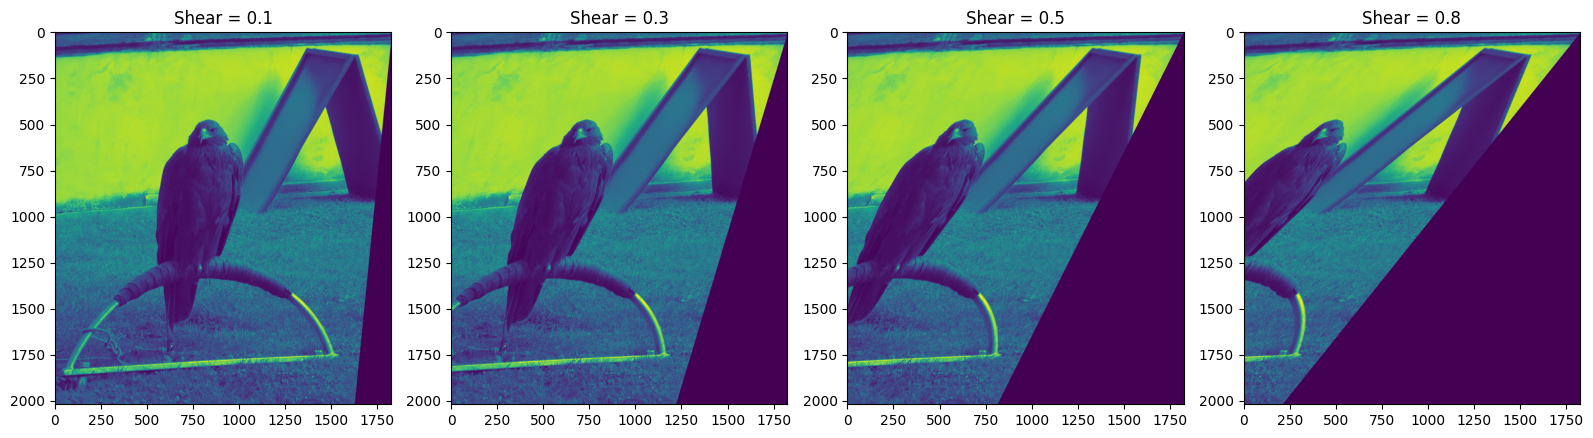

In [76]:
# Experiment with different shear factors
shear_factors = [0.1, 0.3, 0.5, 0.8]

plt.figure(figsize=(16, 5))

for i, shx in enumerate(shear_factors):
    sheared = img.transform((width, height), Image.Transform.AFFINE, (1, shx, 0, 0, 1, 0), resample=Image.Resampling.BICUBIC)

    plt.subplot(1, 4, i + 1)
    plt.imshow(sheared)
    plt.title(f"Shear = {shx}")

plt.tight_layout()
plt.show()

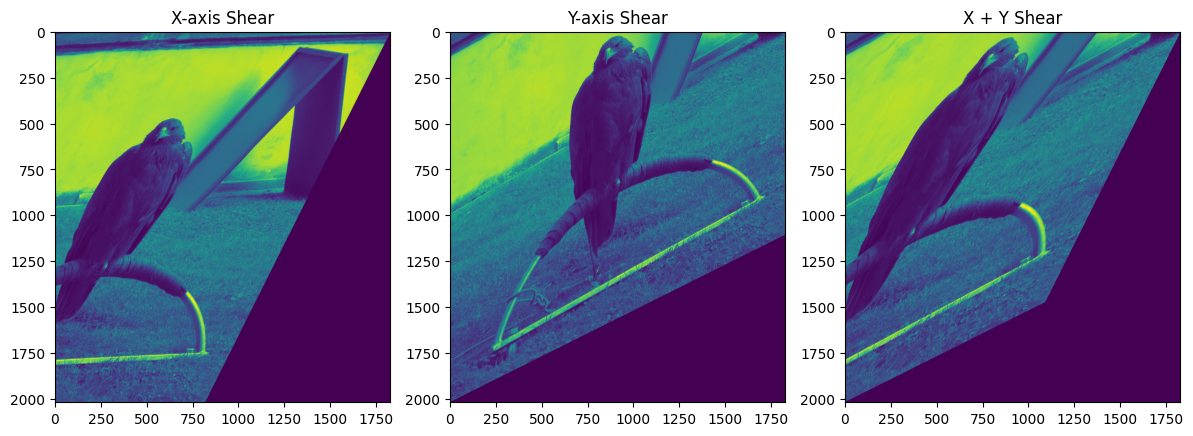

In [77]:
# Compare X-axis, Y-axis, and combined shear
factor = 0.5

x_shear = img.transform((width, height), Image.Transform.AFFINE, (1, factor, 0, 0, 1, 0))

y_shear = img.transform((width, height), Image.Transform.AFFINE, (1, 0, 0, factor, 1, 0))

xy_shear = img.transform((width, height), Image.Transform.AFFINE, (1, factor, 0, factor, 1, 0))

images = [x_shear, y_shear, xy_shear]
titles = ["X-axis Shear", "Y-axis Shear", "X + Y Shear"]

plt.figure(figsize=(12, 5))

for i in range(3):
    plt.subplot(1, 3, i + 1)
    plt.imshow(images[i])
    plt.title(titles[i])

plt.tight_layout()
plt.show()

Increasing the shear factor increases the image slant. X-axis shear changes the image horizontally, while Y-axis shear changes it vertically. Combining X and Y shear produces distortion in both directions.

# Intensity Transformations
Negative · Log · Power Law (Gamma)

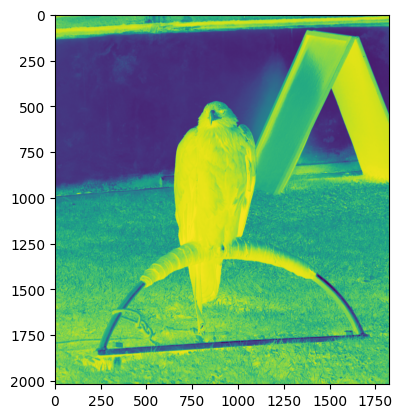

In [78]:

# ── 1. Negative ──────────────────────────────────── 
# Method 1: NumPy array manipulation

img_arr = np.array(img)

negative_arr = 255 - img_arr
negative_img = Image.fromarray(negative_arr.astype(np.uint8))

plt.imshow(negative_img)

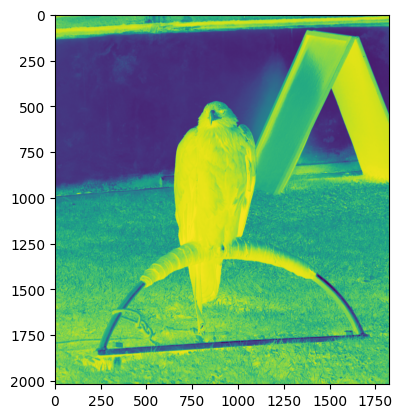

In [79]:
# Method 2: PIL's ImageOps
from PIL import ImageOps
negative_pil = ImageOps.invert(img)

plt.imshow(negative_pil)

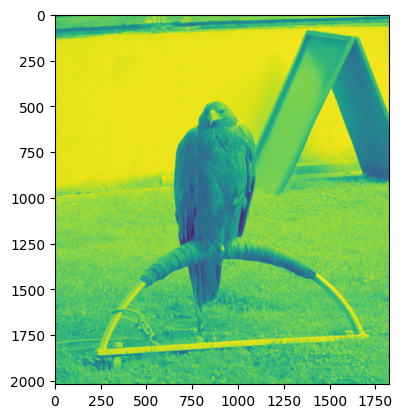

In [80]:
# ── 2. Log transformation ──────────────────────────

# s = c · log(1 + r) --> We need to find c.
# We want the maximum output value (s) to be 255 when the maximum input value (r) is 255:
# 255 = c · log(1 + 255)
# c = 255 / log(1 + 255)

c = 255 / np.log(1 + 255)

# Apply the log transformation to each pixel
img_arr = np.array(img).astype(np.float32)

log_transformed_arr = c * np.log1p(img_arr)
log_transformed_arr = np.clip(log_transformed_arr, 0, 255).astype(np.uint8)

log_img = Image.fromarray(log_transformed_arr)

plt.imshow(log_img)

In [81]:
# ── 3. Power-law / Gamma correction ───────────────
gamma = 0.5

img_arr = np.array(img).astype(np.float32) / 255.0

gamma_arr = 255 * (img_arr ** gamma)
gamma_arr = np.clip(gamma_arr, 0, 255).astype(np.uint8)

gamma_img = Image.fromarray(gamma_arr)

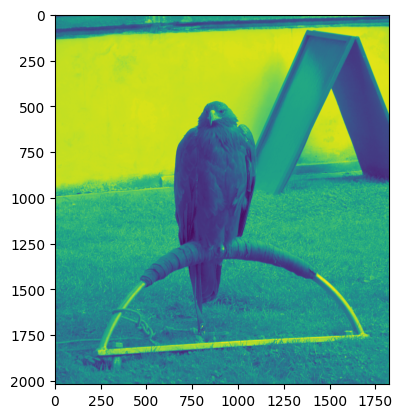

In [82]:
plt.imshow(gamma_img)